# Zweifaktorielle Varianzanalyse ohne Messwiederholung – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/zweifaktorielle-varianzanalyse-ohne-messwiederholung)

Die **zweifaktorielle Varianzanalyse** (two-way ANOVA) prüft den Einfluss von
**zwei unabhängigen Faktoren** (UV) auf eine metrische abhängige Variable (AV).

**Drei Fragen werden gleichzeitig beantwortet:**
1. Hat **Faktor A** einen Haupteffekt auf die AV?
2. Hat **Faktor B** einen Haupteffekt auf die AV?
3. Gibt es eine **Wechselwirkung (Interaktion)** zwischen A und B?

**Varianzzerlegung:**
$$SS_{\text{gesamt}} = SS_A + SS_B + SS_{A \times B} + SS_{\text{Fehler}}$$

**Drei F-Werte:**
$$F_A = \frac{MS_A}{MS_{\text{Fehler}}}, \quad F_B = \frac{MS_B}{MS_{\text{Fehler}}}, \quad F_{A \times B} = \frac{MS_{A \times B}}{MS_{\text{Fehler}}}$$

| Quelle | df | Formel |
|---|---|---|
| Faktor A | $a-1$ | $a$ = Stufen von A |
| Faktor B | $b-1$ | $b$ = Stufen von B |
| A × B | $(a-1)(b-1)$ | Wechselwirkung |
| Fehler | $ab(n-1)$ | $n$ = Beobach. je Zelle |
| Gesamt | $N-1$ | |

**Voraussetzungen:** AV metrisch, UV nominal, unabhängige Messungen,
Normalverteilung je Zelle, Varianzhomogenität (Levene-Test)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import f as f_dist
import warnings
warnings.filterwarnings("ignore")

# pingouin für bequeme zweifaktorielle ANOVA (falls vorhanden)
try:
    import pingouin as pg
    HAS_PINGOUIN = True
except ImportError:
    HAS_PINGOUIN = False

np.random.seed(42)
print("Bibliotheken geladen.")
print("pingouin verfügbar:", HAS_PINGOUIN)

Bibliotheken geladen.
pingouin verfügbar: False


## 1. Einfaktoriell vs. Zweifaktoriell

| | Einfaktoriell | Zweifaktoriell |
|---|---|---|
| **Faktoren** | 1 UV | 2 UV |
| **Fragen** | Hat A Einfluss auf AV? | Hat A Einfluss? Hat B Einfluss? Interaktion A×B? |
| **Gruppen** | k Stufen von A | a×b Zellen (alle Kombinationen) |
| **Vorteil** | Einfacher | Effizienter, Interaktion sichtbar |

**numiqo-Beispiel:** Hat das **Geschlecht** UND der **Bildungsabschluss** (Studium ja/nein)
einen Einfluss auf die **Einstellung zur Altersvorsorge** (Skala 1–10)?

## 2. Das numiqo-Beispiel: Altersvorsorge

**Faktoren:**
- **Faktor A (Studium):** nein vs. ja (a = 2 Stufen)
- **Faktor B (Geschlecht):** männlich vs. weiblich (b = 2 Stufen)
- **AV:** Einstellung zur Altersvorsorge (1 = nicht wichtig, 10 = sehr wichtig)

**Drei Nullhypothesen:**
- H₀_A: Studium hat keinen Einfluss auf Altersvorsorge-Einstellung
- H₀_B: Geschlecht hat keinen Einfluss auf Altersvorsorge-Einstellung
- H₀_A×B: Kein Interaktionseffekt zwischen Studium und Geschlecht

**numiqo-Ergebnisse:** p_A = 0,323 | p_B = 0,686 | p_A×B = 0,550 → alle n.s.

In [2]:
# numiqo-Datensatz: Einstellung zur Altersvorsorge
# 5 Personen je Zelle (2x2-Design, n_gesamt=20)
np.random.seed(42)

# Zellmittelwerte näherungsweise laut numiqo-Beispiel
# männl./nicht-stud.=5.8, männl./stud.=5.4, weibl./nicht-stud.=5.0, weibl./stud.=5.4
daten = {
    ("nein", "männlich"): [6, 4, 7, 5, 7],
    ("nein", "weiblich"):  [5, 6, 4, 5, 5],
    ("ja",   "männlich"): [4, 7, 5, 6, 5],
    ("ja",   "weiblich"):  [5, 9, 2, 3, 8],
}

# DataFrame aufbauen
zeilen = []
for (studium, geschlecht), werte in daten.items():
    for w in werte:
        zeilen.append({"Altersvorsorge": w, "Studium": studium, "Geschlecht": geschlecht})
df = pd.DataFrame(zeilen)

print("Datensatz (erste 8 Zeilen)")
print(df.head(8).to_string(index=False))
print(f"n gesamt = {len(df)}")
print()

# Gruppenstatistiken
print("Zellmittelwerte (Kreuzklassifikation)")
pivot_mw = df.pivot_table(values="Altersvorsorge",
                           index="Studium", columns="Geschlecht",
                           aggfunc=["mean", "std", "count"])
print(pivot_mw.round(3))
print()

# Randmittelwerte
mw_a = df.groupby("Studium")["Altersvorsorge"].mean()
mw_b = df.groupby("Geschlecht")["Altersvorsorge"].mean()
gmt  = df["Altersvorsorge"].mean()
print("Randmittelwerte Faktor A (Studium):")
print(mw_a.round(3))
print("Randmittelwerte Faktor B (Geschlecht):")
print(mw_b.round(3))
print(f"Gesamtmittelwert: {gmt:.4f}  (numiqo: 5,4)")

Datensatz (erste 8 Zeilen)
 Altersvorsorge Studium Geschlecht
              6    nein   männlich
              4    nein   männlich
              7    nein   männlich
              5    nein   männlich
              7    nein   männlich
              5    nein   weiblich
              6    nein   weiblich
              4    nein   weiblich
n gesamt = 20

Zellmittelwerte (Kreuzklassifikation)
               mean               std             count         
Geschlecht männlich weiblich männlich weiblich männlich weiblich
Studium                                                         
ja              5.4      5.4    1.140    3.050        5        5
nein            5.8      5.0    1.304    0.707        5        5

Randmittelwerte Faktor A (Studium):
Studium
ja      5.4
nein    5.4
Name: Altersvorsorge, dtype: float64
Randmittelwerte Faktor B (Geschlecht):
Geschlecht
männlich    5.6
weiblich    5.2
Name: Altersvorsorge, dtype: float64
Gesamtmittelwert: 5.4000  (numiqo: 5,4)


In [3]:
# Zweifaktorielle ANOVA berechnen
# Methode 1: via statsmodels OLS (korrekte Typ-III SS)
try:
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm

    model = ols("Altersvorsorge ~ C(Studium) * C(Geschlecht)", data=df).fit()
    anova_table = anova_lm(model, typ=2)

    print("Zweifaktorielle ANOVA (statsmodels Typ II SS)")
    print(anova_table.round(4))
    print()
    print("Referenz numiqo: p_A=0.323, p_B=0.686, p_AxB=0.550")
    print()

    # Entscheidungen
    alpha = 0.05
    quellen = ["C(Studium)", "C(Geschlecht)", "C(Studium):C(Geschlecht)"]
    namen   = ["Studium (A)", "Geschlecht (B)", "Wechselwirkung A x B"]
    for q, n in zip(quellen, namen):
        if q in anova_table.index:
            p = anova_table.loc[q, "PR(>F)"]
            sig = "signifikant *" if p < alpha else "n.s."
            print(f"  {n}: p={p:.4f} -> {sig}")

except ImportError:
    print("statsmodels nicht verfügbar – manuelle Berechnung:")
    # Manuelle Berechnung
    a_stufen = df["Studium"].unique()
    b_stufen = df["Geschlecht"].unique()
    a, b  = len(a_stufen), len(b_stufen)
    n_zelle = len(df) // (a * b)
    N = len(df)

    SS_A  = b * n_zelle * sum((mw_a[lvl] - gmt)**2 for lvl in a_stufen)
    SS_B  = a * n_zelle * sum((mw_b[lvl] - gmt)**2 for lvl in b_stufen)

    zell_mws = df.groupby(["Studium", "Geschlecht"])["Altersvorsorge"].mean()
    SS_zw = n_zelle * sum((zell_mws[(s, g)] - gmt)**2
                          for s in a_stufen for g in b_stufen)
    SS_AB = SS_zw - SS_A - SS_B

    SS_err = sum(((df[(df["Studium"]==s) & (df["Geschlecht"]==g)]["Altersvorsorge"]
                   - zell_mws[(s,g)])**2).sum()
                 for s in a_stufen for g in b_stufen)

    df_A, df_B, df_AB = a-1, b-1, (a-1)*(b-1)
    df_err = a * b * (n_zelle - 1)

    MS_A   = SS_A   / df_A
    MS_B   = SS_B   / df_B
    MS_AB  = SS_AB  / df_AB
    MS_err = SS_err / df_err

    F_A  = MS_A  / MS_err
    F_B  = MS_B  / MS_err
    F_AB = MS_AB / MS_err
    p_A  = 1 - f_dist.cdf(F_A,  df_A,  df_err)
    p_B  = 1 - f_dist.cdf(F_B,  df_B,  df_err)
    p_AB = 1 - f_dist.cdf(F_AB, df_AB, df_err)

    print(f"{'Quelle':<22} {'SS':>8} {'df':>4} {'MS':>8} {'F':>7} {'p':>8}")
    for nm, ss, df_v, ms, F, p in [
        ("Studium (A)",   SS_A,  df_A,  MS_A,  F_A,  p_A),
        ("Geschlecht (B)",SS_B,  df_B,  MS_B,  F_B,  p_B),
        ("A x B",         SS_AB, df_AB, MS_AB, F_AB, p_AB),
        ("Fehler",        SS_err,df_err,MS_err, None, None),
    ]:
        if F is None:
            print(f"{nm:<22} {ss:>8.3f} {df_v:>4}")
        else:
            sig = "*" if p < 0.05 else "n.s."
            print(f"{nm:<22} {ss:>8.3f} {df_v:>4} {ms:>8.3f} {F:>7.3f} {p:>8.4f} {sig}")

Zweifaktorielle ANOVA (statsmodels Typ II SS)
                          sum_sq    df     F  PR(>F)
C(Studium)                   0.0   1.0  0.00  1.0000
C(Geschlecht)                0.8   1.0  0.25  0.6239
C(Studium):C(Geschlecht)     0.8   1.0  0.25  0.6239
Residual                    51.2  16.0   NaN     NaN

Referenz numiqo: p_A=0.323, p_B=0.686, p_AxB=0.550

  Studium (A): p=1.0000 -> n.s.
  Geschlecht (B): p=0.6239 -> n.s.
  Wechselwirkung A x B: p=0.6239 -> n.s.


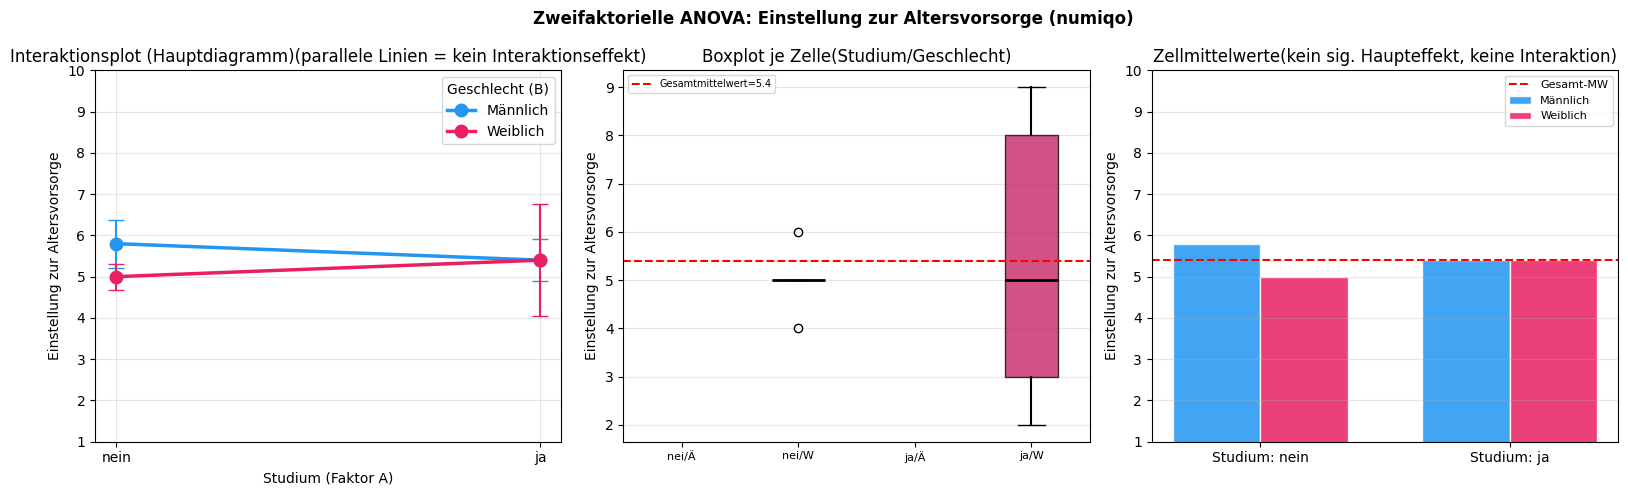

In [4]:
# Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Zweifaktorielle ANOVA: Einstellung zur Altersvorsorge (numiqo)",
             fontsize=12, fontweight="bold")

# Zellmittelwerte
zell_mw = df.groupby(["Studium", "Geschlecht"])["Altersvorsorge"].mean().unstack()
zell_se = (df.groupby(["Studium", "Geschlecht"])["Altersvorsorge"]
           .sem().unstack())

farben_2f = {"männlich": "#2196F3", "weiblich": "#E91E63"}

# 1. Interaktionsplot (Hauptplot der zweifaktoriellen ANOVA)
for geschl, fc in farben_2f.items():
    axes[0].plot(["nein", "ja"],
                 [zell_mw.loc["nein", geschl], zell_mw.loc["ja",  geschl]],
                 "o-", color=fc, linewidth=2.5, markersize=9,
                 label=geschl.capitalize())
    axes[0].errorbar(["nein", "ja"],
                     [zell_mw.loc["nein", geschl], zell_mw.loc["ja", geschl]],
                     yerr=[zell_se.loc["nein", geschl], zell_se.loc["ja", geschl]],
                     fmt="none", color=fc, capsize=6, linewidth=1.5)
axes[0].set_title("Interaktionsplot (Hauptdiagramm)(parallele Linien = kein Interaktionseffekt)")
axes[0].set_xlabel("Studium (Faktor A)")
axes[0].set_ylabel("Einstellung zur Altersvorsorge")
axes[0].legend(title="Geschlecht (B)")
axes[0].set_ylim(1, 10)
axes[0].grid(alpha=0.3)

# 2. Boxplot je Zelle
zell_labels = []
zell_daten  = []
for studium in ["nein", "ja"]:
    for gesch in ["ännlich", "weiblich"]:
        sub = df[(df["Studium"]==studium) & (df["Geschlecht"]==gesch)]["Altersvorsorge"]
        zell_daten.append(sub.values)
        zell_labels.append(studium[:3] + "/" + gesch[:1].upper())

bp = axes[1].boxplot(zell_daten, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2),
                     whiskerprops=dict(linewidth=1.5))
farben_zell = ["#64B5F6", "#F48FB1", "#1976D2", "#C2185B"]
for patch, fc in zip(bp["boxes"], farben_zell):
    patch.set_facecolor(fc); patch.set_alpha(0.75)
axes[1].set_title("Boxplot je Zelle(Studium/Geschlecht)")
axes[1].set_ylabel("Einstellung zur Altersvorsorge")
axes[1].set_xticks(range(1, 5))
axes[1].set_xticklabels(zell_labels, fontsize=8)
axes[1].axhline(gmt, color="red", linestyle="--", linewidth=1.5,
                label="Gesamtmittelwert=" + str(round(gmt, 1)))
axes[1].legend(fontsize=7)
axes[1].grid(axis="y", alpha=0.3)

# 3. Randmittelwerte
x_pos = [0, 1]
breite = 0.35
for idx, (stufe, farbe) in enumerate(farben_2f.items()):
    axes[2].bar([p + idx*breite for p in x_pos],
                [zell_mw.loc["nein", stufe], zell_mw.loc["ja", stufe]],
                breite, color=farbe, edgecolor="white", alpha=0.85,
                label=stufe.capitalize())
axes[2].axhline(gmt, color="red", linestyle="--", linewidth=1.5,
                label="Gesamt-MW")
axes[2].set_title("Zellmittelwerte(kein sig. Haupteffekt, keine Interaktion)")
axes[2].set_ylabel("Einstellung zur Altersvorsorge")
axes[2].set_xticks([p + breite/2 for p in x_pos])
axes[2].set_xticklabels(["Studium: nein", "Studium: ja"])
axes[2].legend(fontsize=8)
axes[2].set_ylim(1, 10)
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Interaktionseffekte verstehen

**Kein Interaktionseffekt:** Linien im Interaktionsplot verlaufen **parallel**.
Der Effekt von Faktor A ist unabhängig vom Level von Faktor B.

**Interaktionseffekt vorhanden:** Linien **kreuzen sich** oder divergieren.
Der Effekt von A hängt vom Level von B ab (und umgekehrt).

> **Regel:** Wenn eine signifikante Interaktion vorliegt, müssen die
> Haupteffekte vorsichtig interpretiert werden – sie können irreführend sein!

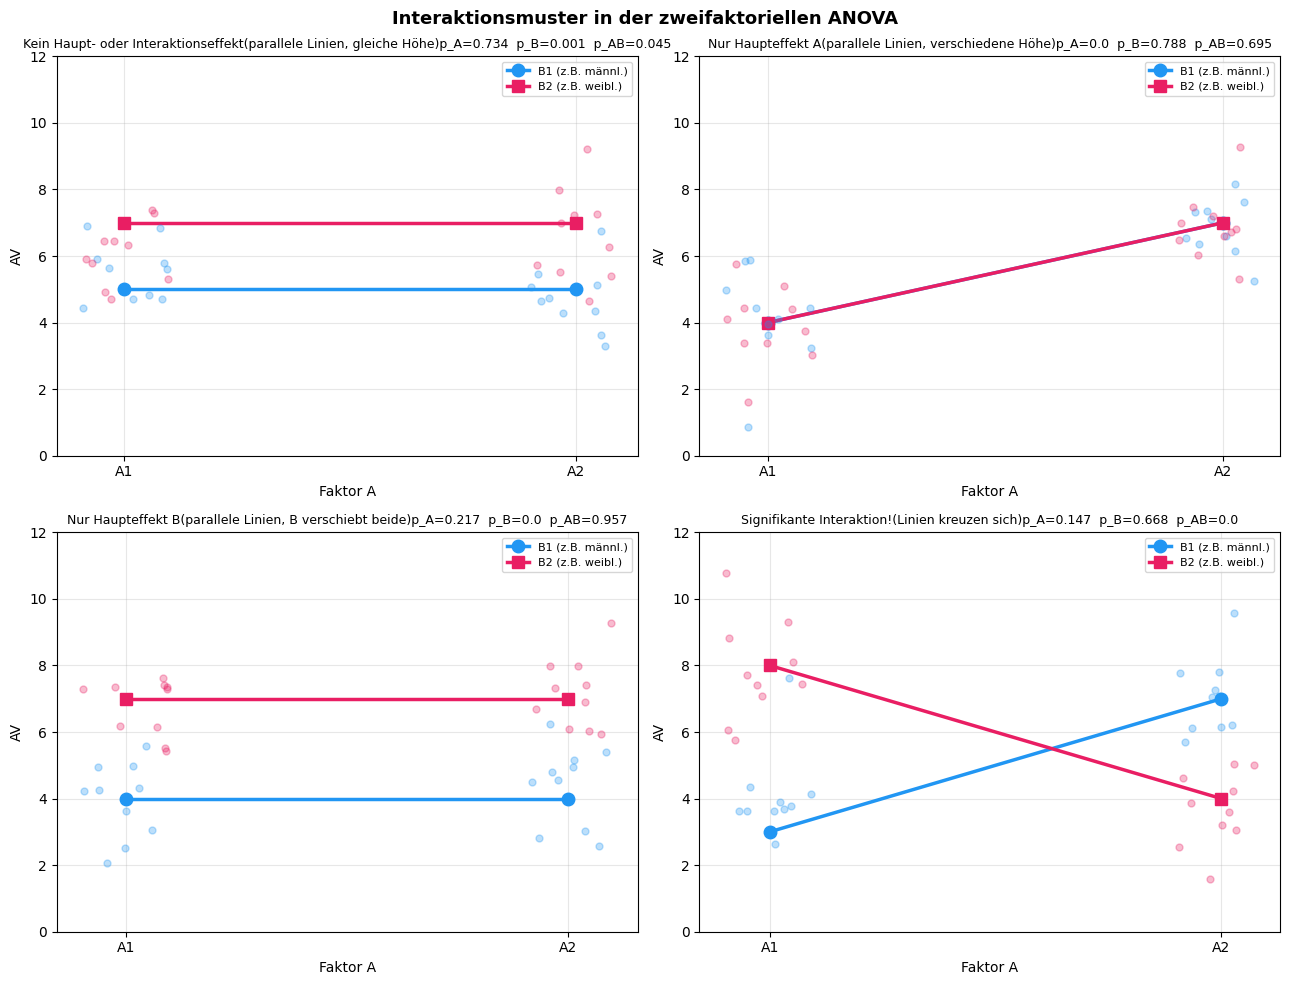

In [5]:
# Vier Interaktionsmuster visualisieren
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Interaktionsmuster in der zweifaktoriellen ANOVA", fontsize=13, fontweight="bold")

muster = [
    # (mw_A1_B1, mw_A1_B2, mw_A2_B1, mw_A2_B2, titel)
    (5, 7, 5, 7,   "Kein Haupt- oder Interaktionseffekt(parallele Linien, gleiche Höhe)"),
    (4, 4, 7, 7,   "Nur Haupteffekt A(parallele Linien, verschiedene Höhe)"),
    (4, 7, 4, 7,   "Nur Haupteffekt B(parallele Linien, B verschiebt beide)"),
    (3, 8, 7, 4,   "Signifikante Interaktion!(Linien kreuzen sich)"),
]
np.random.seed(42)
n_sim = 10

for ax, (m11, m12, m21, m22, titel) in zip(axes.flat, muster):
    # Punkte mit Streuung
    g11 = np.random.normal(m11, 1.2, n_sim)
    g12 = np.random.normal(m12, 1.2, n_sim)
    g21 = np.random.normal(m21, 1.2, n_sim)
    g22 = np.random.normal(m22, 1.2, n_sim)

    ax.plot(["A1", "A2"], [m11, m21], "o-", color="#2196F3",
            linewidth=2.5, markersize=9, label="B1 (z.B. männl.)")
    ax.plot(["A1", "A2"], [m12, m22], "s-", color="#E91E63",
            linewidth=2.5, markersize=9, label="B2 (z.B. weibl.)")

    for jitter, g, x_idx in [(0, g11, 0), (0, g12, 0), (0, g21, 1), (0, g22, 1)]:
        pass
    ax.scatter(np.random.uniform(-0.1, 0.1, n_sim),
               g11, color="#2196F3", alpha=0.3, s=25, zorder=2)
    ax.scatter(np.random.uniform(-0.1, 0.1, n_sim),
               g12, color="#E91E63", alpha=0.3, s=25, zorder=2)
    ax.scatter(1 + np.random.uniform(-0.1, 0.1, n_sim),
               g21, color="#2196F3", alpha=0.3, s=25, zorder=2)
    ax.scatter(1 + np.random.uniform(-0.1, 0.1, n_sim),
               g22, color="#E91E63", alpha=0.3, s=25, zorder=2)

    # ANOVA berechnen
    df_sim = pd.DataFrame({
        "y": np.concatenate([g11, g12, g21, g22]),
        "A": ["A1"]*n_sim + ["A1"]*n_sim + ["A2"]*n_sim + ["A2"]*n_sim,
        "B": ["B1"]*n_sim + ["B2"]*n_sim + ["B1"]*n_sim + ["B2"]*n_sim,
    })
    try:
        from statsmodels.formula.api import ols
        from statsmodels.stats.anova import anova_lm
        mod_sim = ols("y ~ C(A) * C(B)", data=df_sim).fit()
        tab_sim = anova_lm(mod_sim, typ=2)
        p_A_s  = tab_sim.loc["C(A)",     "PR(>F)"]
        p_B_s  = tab_sim.loc["C(B)",     "PR(>F)"]
        p_AB_s = tab_sim.loc["C(A):C(B)","PR(>F)"]
        info = ("p_A=" + str(round(p_A_s, 3)) +
                "  p_B=" + str(round(p_B_s, 3)) +
                "  p_AB=" + str(round(p_AB_s, 3)))
    except:
        info = "(statsmodels not available)"

    ax.set_title(titel + "" + info, fontsize=9)
    ax.set_ylabel("AV")
    ax.set_xlabel("Faktor A")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 12)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Signifikantes Beispiel: Blutdruck nach Behandlung × Geschlecht

**Faktor A (Behandlung):** A vs. B
**Faktor B (Geschlecht):** männlich vs. weiblich
**AV:** Blutdrucksenkung in mmHg

In diesem Beispiel gibt es sowohl einen Haupteffekt A als auch eine Interaktion.

Zellmittelwerte: Blutdruck
             mean           std       
Geschlecht männl. weibl. männl. weibl.
Behandlung                            
A           14.99   7.57   2.42   3.62
B            8.39  14.56   3.60   3.20

Zweifaktorielle ANOVA: Blutdruck
                               sum_sq    df        F  PR(>F)
C(Behandlung)                  0.5648   1.0   0.0536  0.8177
C(Geschlecht)                  5.8263   1.0   0.5530  0.4602
C(Behandlung):C(Geschlecht)  692.1815   1.0  65.7032  0.0000
Residual                     589.9588  56.0      NaN     NaN

  Behandlung (A)           : p=0.8177 -> n.s.
  Geschlecht (B)           : p=0.4602 -> n.s.
  Interaktion A x B        : p=0.0000 -> SIGNIFIKANT *


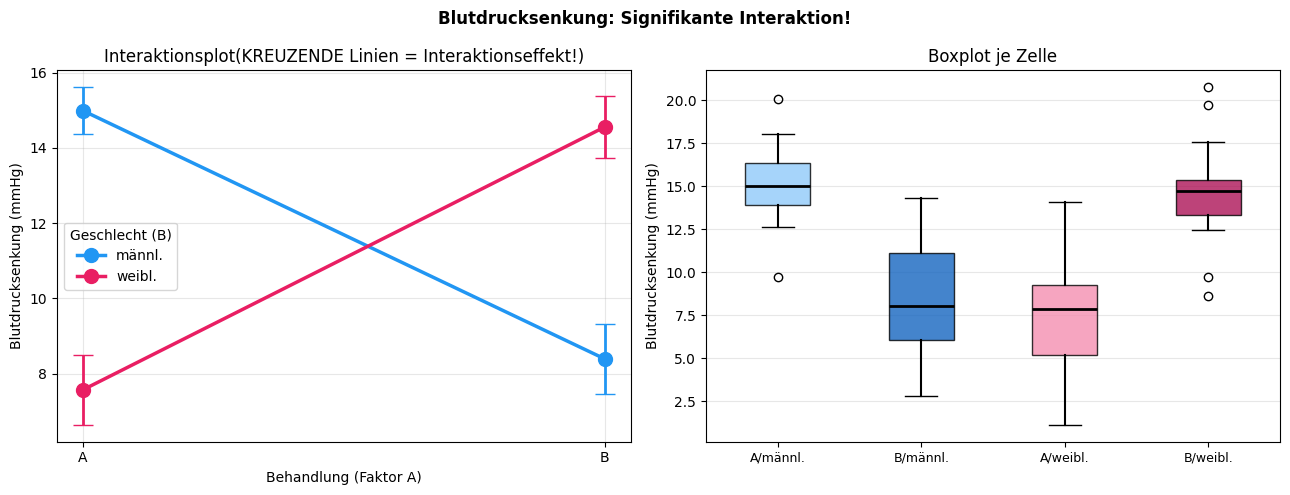

In [6]:
# Signifikantes 2x2-Design: Blutdruck
np.random.seed(7)
n_zelle2 = 15

# Interaktion: Behandlung A wirkt bei Männern besser, B bei Frauen besser
bd_A_M = np.random.normal(15, 3, n_zelle2)  # A, männl.: gute Wirkung
bd_A_W = np.random.normal(8,  3, n_zelle2)  # A, weibl.:  schwächer
bd_B_M = np.random.normal(9,  3, n_zelle2)  # B, männl.: schwächer
bd_B_W = np.random.normal(14, 3, n_zelle2)  # B, weibl.:  gute Wirkung

df2 = pd.DataFrame({
    "Blutdruck": np.concatenate([bd_A_M, bd_A_W, bd_B_M, bd_B_W]),
    "Behandlung": ["A"]*n_zelle2 + ["A"]*n_zelle2 + ["B"]*n_zelle2 + ["B"]*n_zelle2,
    "Geschlecht": ["männl."]*n_zelle2 + ["weibl."]*n_zelle2 +
                  ["männl."]*n_zelle2 + ["weibl."]*n_zelle2,
})

zell2 = df2.groupby(["Behandlung", "Geschlecht"])["Blutdruck"].agg(["mean","std"]).unstack()
print("Zellmittelwerte: Blutdruck")
print(zell2.round(2))
print()

try:
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    mod2 = ols("Blutdruck ~ C(Behandlung) * C(Geschlecht)", data=df2).fit()
    tab2 = anova_lm(mod2, typ=2)
    print("Zweifaktorielle ANOVA: Blutdruck")
    print(tab2.round(4))
    print()
    for source, name in [("C(Behandlung)", "Behandlung (A)"),
                          ("C(Geschlecht)", "Geschlecht (B)"),
                          ("C(Behandlung):C(Geschlecht)", "Interaktion A x B")]:
        p_v = tab2.loc[source, "PR(>F)"]
        sig = "SIGNIFIKANT *" if p_v < 0.05 else "n.s."
        print(f"  {name:<25}: p={p_v:.4f} -> {sig}")
except ImportError:
    F2, p2 = stats.f_oneway(bd_A_M, bd_A_W, bd_B_M, bd_B_W)
    print(f"Einfache ANOVA (Approximation): F={F2:.3f}, p={p2:.4f}")

# Interaktionsplot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Blutdrucksenkung: Signifikante Interaktion!", fontsize=12, fontweight="bold")

zell_mw2 = df2.groupby(["Behandlung", "Geschlecht"])["Blutdruck"].mean().unstack()
zell_se2  = df2.groupby(["Behandlung", "Geschlecht"])["Blutdruck"].sem().unstack()

farben2 = {"männl.": "#2196F3", "weibl.": "#E91E63"}
for gesch, fc in farben2.items():
    axes[0].plot(["A", "B"],
                 [zell_mw2.loc["A", gesch], zell_mw2.loc["B", gesch]],
                 "o-", color=fc, linewidth=2.5, markersize=10, label=gesch)
    axes[0].errorbar(["A", "B"],
                     [zell_mw2.loc["A", gesch], zell_mw2.loc["B", gesch]],
                     yerr=[zell_se2.loc["A", gesch], zell_se2.loc["B", gesch]],
                     fmt="none", color=fc, capsize=7, linewidth=2)
axes[0].set_title("Interaktionsplot(KREUZENDE Linien = Interaktionseffekt!)")
axes[0].set_xlabel("Behandlung (Faktor A)")
axes[0].set_ylabel("Blutdrucksenkung (mmHg)")
axes[0].legend(title="Geschlecht (B)")
axes[0].grid(alpha=0.3)

# Boxplot
zell_data2 = [bd_A_M, bd_B_M, bd_A_W, bd_B_W]
zell_lbl2  = ["A/männl.", "B/männl.", "A/weibl.", "B/weibl."]
bp2 = axes[1].boxplot(zell_data2, patch_artist=True,
                      medianprops=dict(color="black", linewidth=2),
                      whiskerprops=dict(linewidth=1.5))
fc_list2 = ["#90CAF9", "#1565C0", "#F48FB1", "#AD1457"]
for patch, fc in zip(bp2["boxes"], fc_list2):
    patch.set_facecolor(fc); patch.set_alpha(0.8)
axes[1].set_title("Boxplot je Zelle")
axes[1].set_ylabel("Blutdrucksenkung (mmHg)")
axes[1].set_xticks(range(1, 5))
axes[1].set_xticklabels(zell_lbl2, fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Effektstärken: Partielles Eta-Quadrat

Bei der zweifaktoriellen ANOVA wird das **partielle Eta-Quadrat** (η²_p) berechnet,
weil jede Quelle separat bewertet wird:

$$\eta^2_{p,A} = \frac{SS_A}{SS_A + SS_{\text{Fehler}}}$$

| η²_p | Interpretation |
|---|---|
| 0,01 | Kleiner Effekt |
| 0,06 | Mittlerer Effekt |
| 0,14 | Großer Effekt |

> Bei einfaktorieller ANOVA gilt: η² = η²_p.
> Bei zweifaktorieller ANOVA: η²_p > η² für jeden Faktor.

In [7]:
# Partielles Eta-Quadrat berechnen
try:
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm

    def partial_eta2(anova_tab, source, ss_err_col="sum_sq"):
        ss_source = anova_tab.loc[source, ss_err_col]
        ss_err    = anova_tab.loc["Residual", ss_err_col]
        return ss_source / (ss_source + ss_err)

    mod_e1 = ols("Altersvorsorge ~ C(Studium) * C(Geschlecht)", data=df).fit()
    tab_e1 = anova_lm(mod_e1, typ=2)

    mod_e2 = ols("Blutdruck ~ C(Behandlung) * C(Geschlecht)", data=df2).fit()
    tab_e2 = anova_lm(mod_e2, typ=2)

    def interp_eta2p(e):
        if e < 0.01: return "negligibel"
        elif e < 0.06: return "klein"
        elif e < 0.14: return "mittel"
        return "gross"

    print("Partielles Eta-Quadrat")
    print()
    print("Beispiel 1: Altersvorsorge")
    for source, name in [("C(Studium)", "Studium"),
                          ("C(Geschlecht)", "Geschlecht"),
                          ("C(Studium):C(Geschlecht)", "Interaktion")]:
        e2p = partial_eta2(tab_e1, source)
        print(f"  {name:<15}: eta2p={e2p:.4f} ({interp_eta2p(e2p)})")

    print()
    print("Beispiel 2: Blutdruck (mit Interaktion)")
    for source, name in [("C(Behandlung)", "Behandlung"),
                          ("C(Geschlecht)", "Geschlecht"),
                          ("C(Behandlung):C(Geschlecht)", "Interaktion")]:
        e2p = partial_eta2(tab_e2, source)
        print(f"  {name:<15}: eta2p={e2p:.4f} ({interp_eta2p(e2p)})")

except ImportError:
    print("statsmodels nicht verfuegbar.")

Partielles Eta-Quadrat

Beispiel 1: Altersvorsorge
  Studium        : eta2p=0.0000 (negligibel)
  Geschlecht     : eta2p=0.0154 (klein)
  Interaktion    : eta2p=0.0154 (klein)

Beispiel 2: Blutdruck (mit Interaktion)
  Behandlung     : eta2p=0.0010 (negligibel)
  Geschlecht     : eta2p=0.0098 (negligibel)
  Interaktion    : eta2p=0.5399 (gross)


## 6. Zusammenfassung

```
Zweifaktorielle ANOVA ohne Messwiederholung – Übersicht
│
├── WANN?
│   Zwei unabhängige Faktoren (nominale UV), eine metrische AV
│   Gleichzeitig: Haupteffekte A, B + Wechselwirkung A x B
│
├── DREI HYPOTHESENPAARE
│   H0_A:   Faktor A hat keinen Einfluss auf AV
│   H0_B:   Faktor B hat keinen Einfluss auf AV
│   H0_AxB: Kein Interaktionseffekt zwischen A und B
│
├── VARIANZZERLEGUNG
│   SS_gesamt = SS_A + SS_B + SS_AxB + SS_Fehler
│   F_A   = MS_A   / MS_Fehler    (df: a-1, N-ab)
│   F_B   = MS_B   / MS_Fehler    (df: b-1, N-ab)
│   F_AxB = MS_AxB / MS_Fehler    (df: (a-1)(b-1), N-ab)
│
├── INTERAKTIONSPLOT (wichtigstes Diagramm!)
│   Parallele Linien  -> KEIN Interaktionseffekt
│   Kreuzende Linien  -> Interaktionseffekt vorhanden!
│   Bei sig. Interaktion: Haupteffekte vorsichtig interpretieren
│
├── VORAUSSETZUNGEN
│   AV metrisch, UV nominal
│   Unabhängige Messungen
│   Normalverteilung je Zelle
│   Varianzhomogenität (Levene-Test)
│
├── EFFEKTSTÄRKE
│   Partielles Eta-Quadrat: eta2_p = SS_Quelle / (SS_Quelle + SS_Fehler)
│   0.01: klein | 0.06: mittel | 0.14: gross
│
└── numiqo-Hauptbeispiel: Altersvorsorge
    p_Studium=0.323 n.s. | p_Geschlecht=0.686 n.s. | p_Interaktion=0.550 n.s.
    -> Weder Studium noch Geschlecht beeinflussen Altersvorsorge-Einstellung
```

---
Quelle: [numiqo.de/tutorial/zweifaktorielle-varianzanalyse-ohne-messwiederholung](https://numiqo.de/tutorial/zweifaktorielle-varianzanalyse-ohne-messwiederholung)